# Riskfolio Example 1

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
from marketmaven.configs import TickerConfig, Interval, Horizon
from marketmaven.asset_prices import build_long_panel, fetch_etf_features
from marketmaven.market_fundamentals import fetch_macro_features
import riskfolio as rp
from marketmaven.configs import (
    RiskfolioConfig, OptModel, RiskMeasure, Objective, MuEstimator, CovEstimator)
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format



# Tickers of assets 
assets = ['ESGD', 'ISCF', 'HYEM', 'SNPE', "VBK", "IEF", 'AVEM','VWOB','VNQI', 'VNQ','BYLD'] # , 'AGEPX', 'SWSSX', 'SWVXX' mutual funds, non tested 'XMMO', 'XMMO'
assets.sort()

config = TickerConfig(
    start_date="2019-10-18",
    end_date="2025-10-18",
    interval=Interval.DAILY,
    tickers=assets,  
    horizon=Horizon.MONTHLY,
)

df = build_long_panel(config.tickers, config.start_date, config.end_date, horizon=config.horizon)
df

,date,asset_id,y_excess_lead
0,2019-10-31,AVEM,-0.0784%
1,2019-10-31,BYLD,0.1033%
2,2019-10-31,ESGD,0.9184%
3,2019-10-31,HYEM,0.3475%
4,2019-10-31,IEF,-0.8136%
...,...,...,...
787,2025-09-30,SNPE,-0.2317%
788,2025-09-30,VBK,0.6466%
789,2025-09-30,VNQ,-0.4713%
790,2025-09-30,VNQI,-0.1566%


In [119]:
# Pivot to wide format: rows = date, columns = asset_id, values = y_excess_lead
y = (
    df.pivot_table(
        index='date',
        columns='asset_id',
        values='y_excess_lead'
    )
    .sort_index()
)

# Optional: remove column index name and return to a regular column layout
y.columns.name = None
y = y.reset_index()
y.index = y['date']
y = y.drop(columns=['date'])

y.head(10)

,AVEM,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,VWOB
date,,,,,,,,,,,
2019-10-31,-0.0784%,0.1033%,0.9184%,0.3475%,-0.8136%,3.0815%,3.6529%,6.0279%,-1.4300%,-0.8489%,-0.6915%
2019-11-29,7.9188%,0.6434%,3.1055%,2.0335%,-1.0594%,5.3307%,2.8976%,1.3680%,0.6355%,3.7820%,2.5381%
2019-12-31,-6.5572%,1.2517%,-2.8542%,1.2934%,3.3235%,-2.8152%,0.5786%,-0.4541%,1.0894%,-2.8077%,1.2608%
2020-01-31,-4.4298%,0.3317%,-7.2739%,-1.4450%,2.8390%,-9.6702%,-9.4068%,-6.8664%,-7.1373%,-5.9721%,-1.5438%
2020-02-28,-19.3244%,-5.1199%,-14.3868%,-15.1938%,3.7006%,-18.1178%,-10.7850%,-18.5157%,-19.4090%,-20.7594%,-12.8704%
2020-03-31,9.2372%,2.6776%,5.6141%,2.9251%,0.2654%,11.2363%,12.9407%,16.4357%,8.9513%,4.0447%,2.8439%
2020-04-30,3.0557%,1.5216%,5.3509%,7.9650%,0.3182%,6.7565%,4.5393%,10.8285%,1.7249%,2.4093%,6.1529%
2020-05-29,6.5280%,0.5001%,3.3823%,2.2030%,0.0300%,2.0418%,2.5191%,2.9478%,2.4120%,2.0207%,2.4269%
2020-06-30,8.0438%,1.8244%,2.2344%,3.4531%,0.8437%,3.7697%,5.8239%,5.8457%,3.6312%,1.5755%,3.7525%


In [120]:
y.tail()

,AVEM,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,VWOB
date,,,,,,,,,,,
2025-05-30,7.3610%,1.3394%,2.2178%,1.4455%,1.2453%,4.4826%,5.4183%,4.7647%,0.3350%,4.1159%,2.1275%
2025-06-30,0.5298%,-0.1738%,-2.5518%,0.5285%,-0.9774%,-0.7558%,2.1361%,1.5745%,-0.2963%,-2.3932%,0.3449%
2025-07-31,2.4239%,0.7738%,3.6769%,1.5517%,1.3002%,4.0025%,2.1359%,3.4197%,3.1234%,3.8009%,1.3654%
2025-08-29,5.2945%,1.0358%,2.0517%,-0.3310%,0.3079%,1.6739%,3.2171%,1.3607%,-0.2835%,1.0132%,1.1314%
2025-09-30,1.1170%,0.3258%,0.8857%,-0.5237%,1.0719%,-1.2055%,-0.2317%,0.6466%,-0.4713%,-0.1566%,0.7968%


In [121]:
y.corr()

import plotly.express as px

# Compute the correlation matrix
corr_matrix = y.corr()

# Create a heatmap using Plotly
fig = px.imshow(
    corr_matrix,
    labels=dict(color="Correlation"),
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    color_continuous_scale="RdYlBu",
    title="Correlation Heatmap",
    zmin=-1,
    zmax=1,
)

fig.update_layout(width=600, height=600)
fig.show()

## Estimating Mean Variance Portfolio

**Direct Comparison**

Aspect	JS + Ledoit	EWMA2 + Gerber1
Mean estimator bias/variance	Lower variance (shrinkage), slower	Higher variance, faster
Regime responsiveness	Moderate / slow	Fast
Covariance robustness (tails)	Good (shrinkage)	Higher (tail robust)
Conditioning	Strong	Strong (slightly lower κ)
Turnover	Lower	Higher
Tail crash behavior	Adequate	More protective (potential faster de‑risk)
Interpretability	High	Moderate
Risk of overfitting	Lower	Higher
Selection Heuristic

If you need a dependable benchmark portfolio: use JS + Ledoit.
If recent months show sharp volatility clustering or correlation spikes and you want the model to react: test EWMA2 + Gerber1.
You can blend: use JS mean but Gerber1 covariance (stable expected returns + tail‑robust risk) or EWMA2 mean with Ledoit covariance (fast mean, stable Σ).

In [122]:
config = RiskfolioConfig(
    model=OptModel.CLASSIC,
    rm=RiskMeasure.CVaR,
    obj=Objective.SHARPE,
    method_mu=MuEstimator.EWMA2,
    method_cov=CovEstimator.GERBER1,

)

# Build portfolio
port = rp.Portfolio(returns=y)

# Estimate stats (you can pass decay d for EWMA or shrinkage)
port.assets_stats(method_mu=config.method_mu, method_cov=config.method_cov)

# Constraints
port.upperlng = 0.35  # max per asset
port.card = None      # no strict cardinality selection
port.nea = 6          # desired effective assets (soft)



# Optimize (mean-variance / Sharpe)
w = port.optimization(
    model=config.model,
    rm=config.rm,
    obj=config.obj,
    rf=config.rf,
    l=config.ra,
    hist=config.hist  # MV does not need scenario risk
)

print("Weights:")
display(w.T)

# Diagnostics
print("Mu (monthly):")
print(port.mu)

Weights:


,AVEM,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,VWOB
weights,21.2906%,9.4302%,13.8030%,0.6948%,11.2557%,12.5172%,24.9727%,5.0455%,0.0000%,0.0000%,0.9903%


Mu (monthly):
     AVEM    BYLD    ESGD    HYEM      IEF    ISCF    SNPE     VBK     VNQ  \
0 1.2805% 0.1739% 0.9440% 0.3146% -0.0231% 1.1002% 1.2048% 0.8488% 0.1811%   

     VNQI    VWOB  
0 0.5159% 0.3661%  


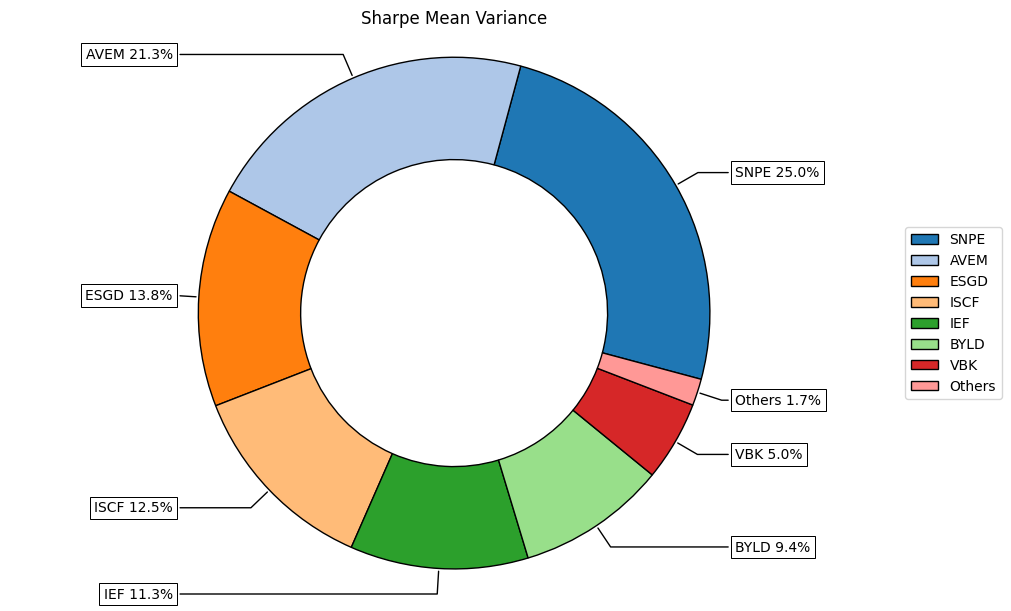

In [123]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w, title='Sharpe Mean Variance', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [124]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=config.model, rm=config.rm, points=points, rf=config.rf, hist=config.hist)

display(frontier.T.head())

,AVEM,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,VWOB
0,3.6361%,21.9828%,6.8829%,12.9911%,27.4479%,2.6169%,7.5236%,1.3908%,3.1431%,1.2571%,11.1278%
1,6.9049%,21.5886%,8.3516%,11.1031%,27.0494%,4.1090%,11.3166%,0.4632%,0.0000%,0.0000%,9.1136%
2,8.3255%,21.3033%,8.7564%,9.6159%,26.9293%,4.3974%,13.1813%,0.0000%,0.0000%,0.0000%,7.4909%
3,9.3640%,20.9915%,9.0381%,8.4879%,26.7040%,4.6208%,14.5178%,0.0000%,0.0000%,0.0000%,6.2760%
4,10.2528%,20.6447%,9.3066%,7.6019%,26.3679%,4.8877%,15.5963%,0.0000%,0.0000%,0.0000%,5.3420%


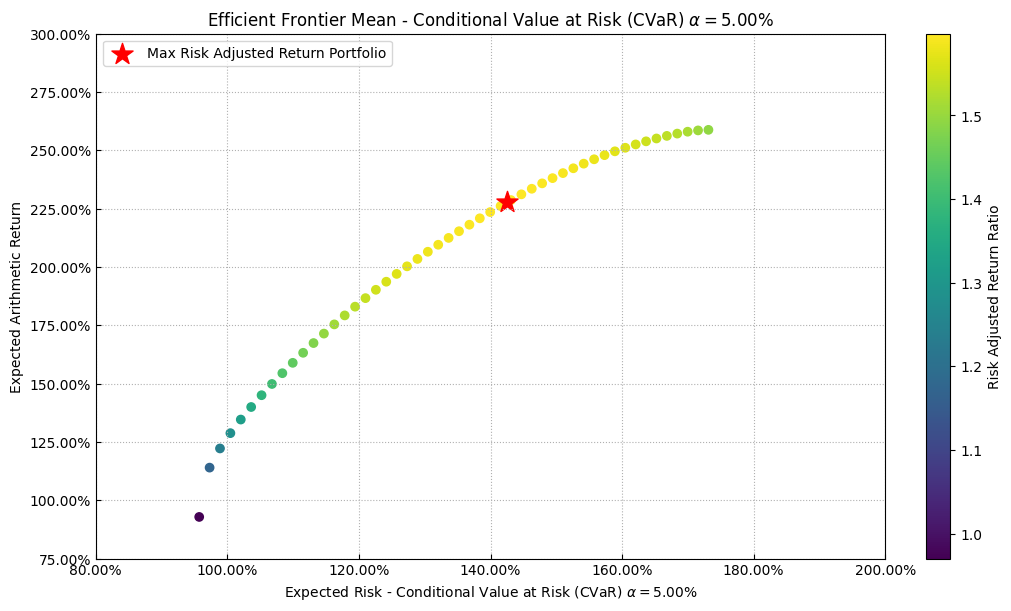

In [125]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(w_frontier=frontier, mu=mu, cov=cov, returns=returns, rm=config.rm,
                      rf=config.rf, alpha=0.05, cmap='viridis', w=w, label=label,
                      marker='*', s=16, c='r', height=6, width=10, ax=None)

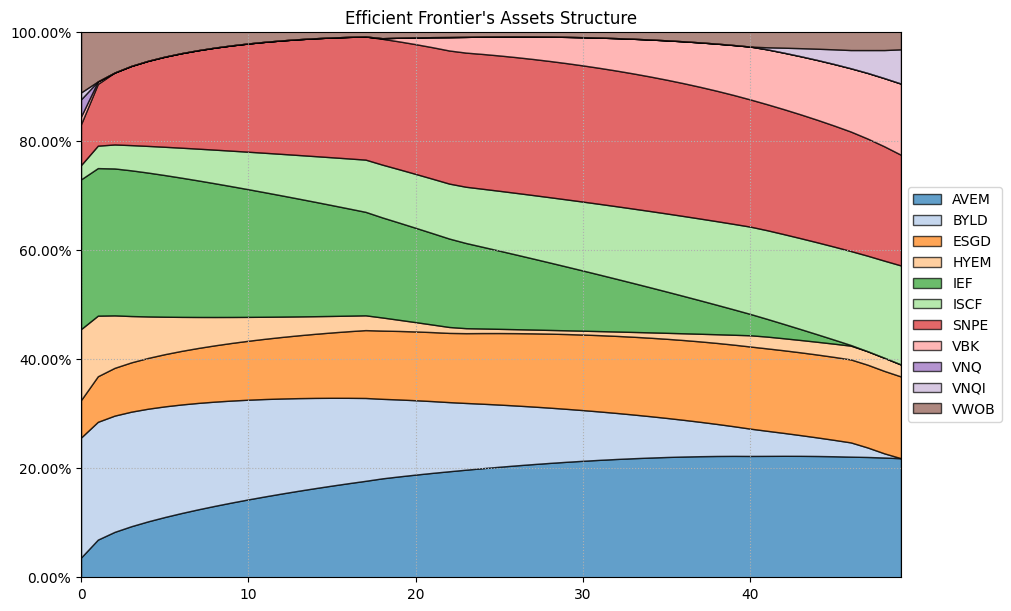

In [126]:
# Plotting efficient frontier composition

ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

In [127]:
# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'MAD': Mean Absolute Deviation.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.

rms = ['MV', 'MAD', 'MSV', 'FLPM', 'SLPM', 'CVaR',
       'EVaR', 'WR', 'MDD', 'ADD', 'CDaR', 'UCI', 'EDaR']

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=config.model, rm=i, obj=config.obj, rf=config.rf, l=config.ra, hist=config.hist)
    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = rms
w_s.style.format("{:.2%}").background_gradient(cmap='YlGn')

,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
AVEM,24.09%,24.00%,23.82%,23.43%,23.77%,21.29%,14.52%,11.78%,21.67%,16.89%,19.33%,18.65%,20.53%
BYLD,13.41%,10.26%,9.93%,9.99%,9.89%,9.43%,11.00%,11.81%,8.51%,8.17%,9.39%,8.31%,8.66%
ESGD,11.51%,11.33%,12.12%,10.98%,12.34%,13.80%,13.27%,12.83%,12.43%,16.69%,13.02%,16.68%,13.11%
HYEM,6.04%,7.01%,4.70%,8.49%,4.16%,0.69%,0.00%,0.00%,3.39%,5.49%,0.99%,4.40%,2.85%
IEF,6.71%,5.78%,8.16%,4.58%,8.63%,11.26%,18.98%,22.39%,1.15%,0.64%,5.77%,1.65%,2.02%
ISCF,13.03%,14.16%,12.93%,14.26%,12.73%,12.52%,10.84%,9.92%,17.97%,15.44%,16.60%,17.01%,17.76%
SNPE,22.75%,23.66%,24.27%,24.18%,24.26%,24.97%,25.76%,24.51%,23.68%,26.60%,26.00%,24.94%,24.51%
VBK,0.15%,0.00%,1.54%,0.05%,1.93%,5.05%,3.78%,3.84%,8.16%,7.12%,6.69%,5.44%,7.91%
VNQ,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
VNQI,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.33%,0.00%,0.00%,0.00%,0.00%


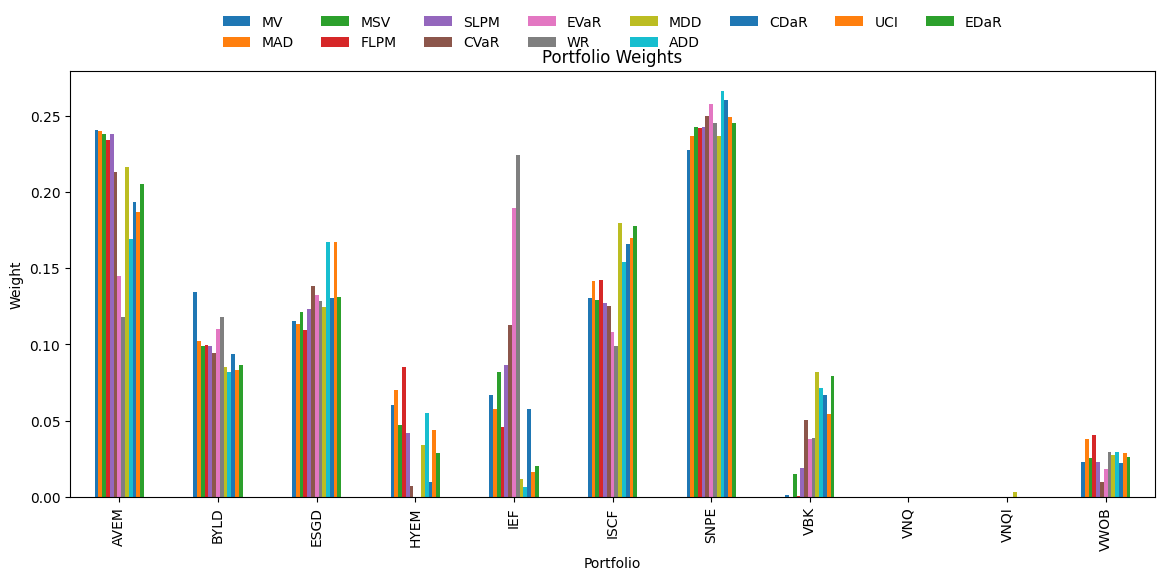

In [68]:
import matplotlib.pyplot as plt

# Assume w_s is a DataFrame: rows = portfolios (or 1 row), columns = assets (weights)
# If it's a Series, convert first: w_s = w_s.to_frame().T

fig, ax = plt.subplots(figsize=(14, 6))
w_s.plot.bar(ax=ax)

ax.set_ylabel("Weight")
ax.set_xlabel("Portfolio" if w_s.shape[0] > 1 else "")
ax.set_title("Portfolio Weights")

# Move legend above plot, horizontal
handles, labels = ax.get_legend_handles_labels()
ncol = min(len(labels), 8)  # wrap if many assets
legend = ax.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=ncol,
    frameon=False,
)

# Add a little extra top margin for the legend
plt.subplots_adjust(top=0.82)

plt.show()

# CVAR

In [10]:
config2 = RiskfolioConfig(
    model=OptModel.CLASSIC,
    rm=RiskMeasure.CVaR,
    obj=Objective.SHARPE,
)



w = port.optimization(model=config2.model, rm=config2.rm, obj=config2.obj, rf=config2.rf, l=config2.ra, hist=config2.hist)

display(w.T)

,AVEM,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,VWOB
weights,12.8763%,7.9821%,13.1573%,4.2970%,7.5647%,10.9984%,30.1455%,12.5889%,0.0000%,0.0000%,0.3898%


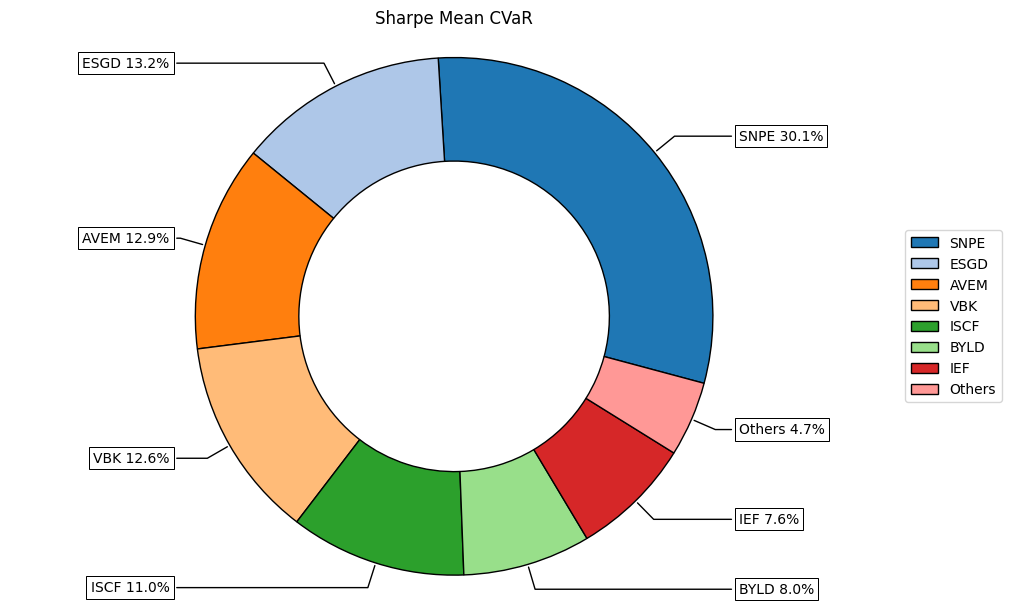

In [11]:
ax = rp.plot_pie(w=w, title='Sharpe Mean CVaR', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [33]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=config2.model, rm=config2.rm, points=points, rf=config2.rf, hist=config2.hist)

display(frontier.T.head())

,AVEM,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,VWOB
0,0.03636,0.2198,0.06883,0.1299,0.2745,0.02617,0.07524,0.0139,0.03143,0.01258,0.1113
1,0.04528,0.2161,0.07901,0.1171,0.269,0.03114,0.1289,0.02068,0.005696,2.442e-11,0.08722
2,0.04836,0.2125,0.08254,0.1097,0.2644,0.03242,0.1525,0.02285,1.444e-10,2.489e-11,0.07469
3,0.05046,0.2089,0.08493,0.1032,0.2599,0.0331,0.1711,0.02427,2.922e-10,6.33e-11,0.06412
4,0.05266,0.2052,0.08712,0.0979,0.255,0.03425,0.1861,0.0261,6.104e-11,1.424e-11,0.05568


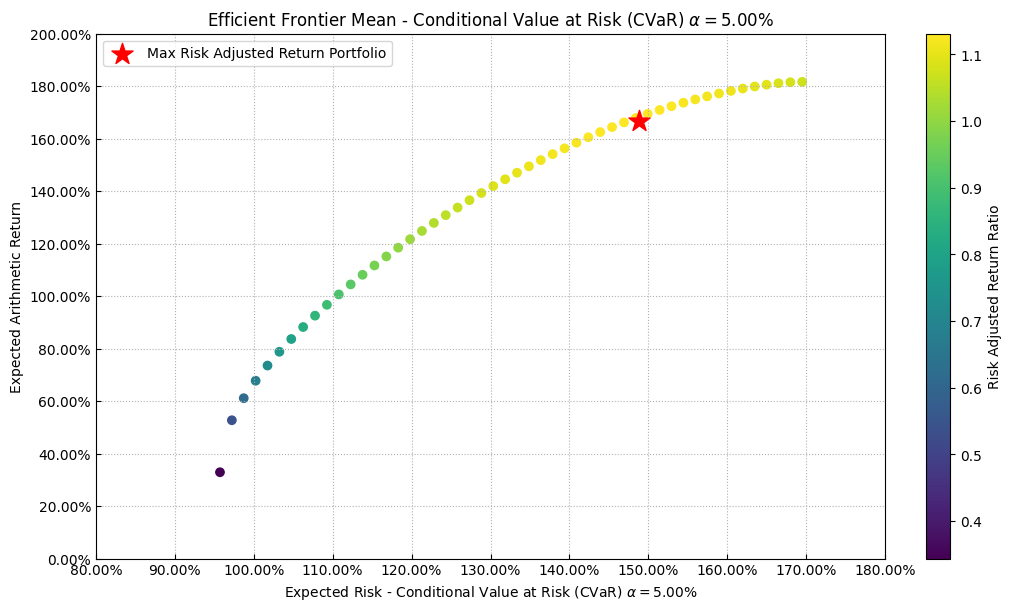

In [34]:
label = 'Max Risk Adjusted Return Portfolio' # Title of point

ax = rp.plot_frontier(w_frontier=frontier, mu=mu, cov=cov, returns=returns, rm=config2.rm,
                      rf=config2.rf, alpha=0.05, cmap='viridis', w=w, label=label,
                      marker='*', s=16, c='r', height=6, width=10, ax=None)

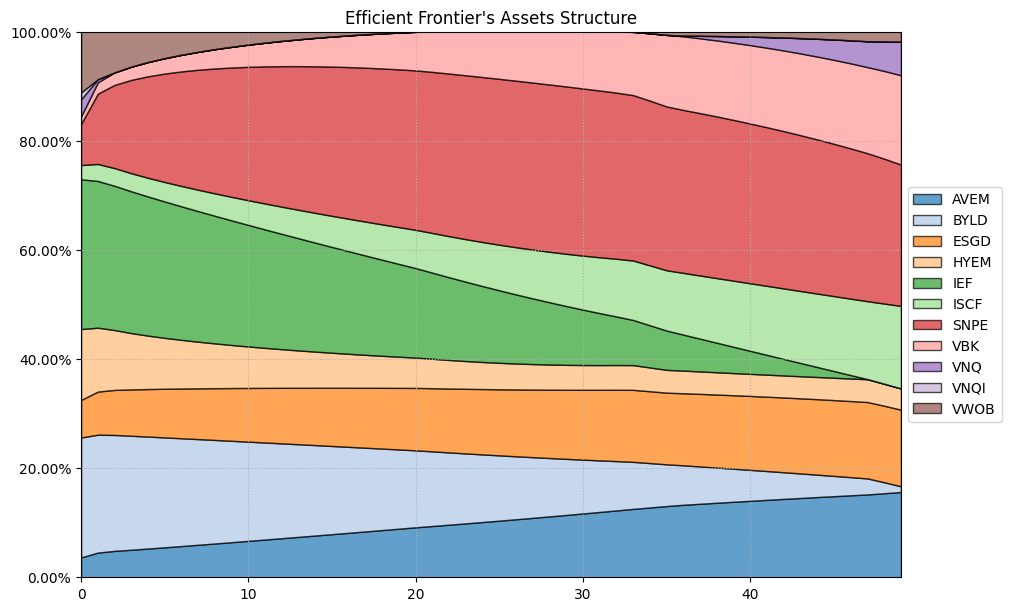

In [14]:
# Plotting efficient frontier composition

ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

In [ ]:
# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'MAD': Mean Absolute Deviation.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.

rms = ['MV', 'MAD', 'MSV', 'FLPM', 'SLPM', 'CVaR',
       'EVaR', 'WR', 'MDD', 'ADD', 'CDaR', 'UCI', 'EDaR']

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=config2.model, rm=i, obj=config2.obj, rf=config2.rf, l=config2.ra, hist=config.hist)
    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = rms

In [36]:
w_s.style.format("{:.2%}").background_gradient(cmap='YlGn')

,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
AVEM,14.79%,15.71%,15.17%,16.27%,15.06%,12.88%,9.77%,8.70%,14.53%,13.28%,12.47%,14.04%,14.03%
BYLD,8.27%,8.41%,8.06%,8.31%,8.04%,7.98%,9.38%,9.95%,7.31%,7.70%,8.02%,7.61%,7.43%
ESGD,12.10%,11.60%,12.40%,11.65%,12.45%,13.16%,12.88%,12.76%,12.01%,15.65%,12.36%,15.49%,12.53%
HYEM,6.67%,7.73%,6.17%,8.53%,6.00%,4.30%,1.98%,1.24%,4.71%,6.43%,3.50%,5.51%,4.48%
IEF,5.19%,4.23%,5.75%,3.75%,5.94%,7.56%,13.79%,16.25%,1.24%,1.20%,4.62%,1.88%,1.78%
ISCF,11.68%,11.99%,11.18%,11.42%,11.07%,11.00%,9.92%,9.57%,14.44%,13.81%,13.25%,14.70%,14.38%
SNPE,30.63%,30.43%,30.31%,30.14%,30.31%,30.15%,30.05%,29.33%,28.98%,28.82%,30.33%,28.50%,29.23%
VBK,9.23%,7.98%,10.13%,8.32%,10.34%,12.59%,10.96%,10.41%,13.37%,10.81%,12.69%,10.28%,12.94%
VNQ,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,2.37%,0.00%,1.83%,0.07%,2.12%
VNQI,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


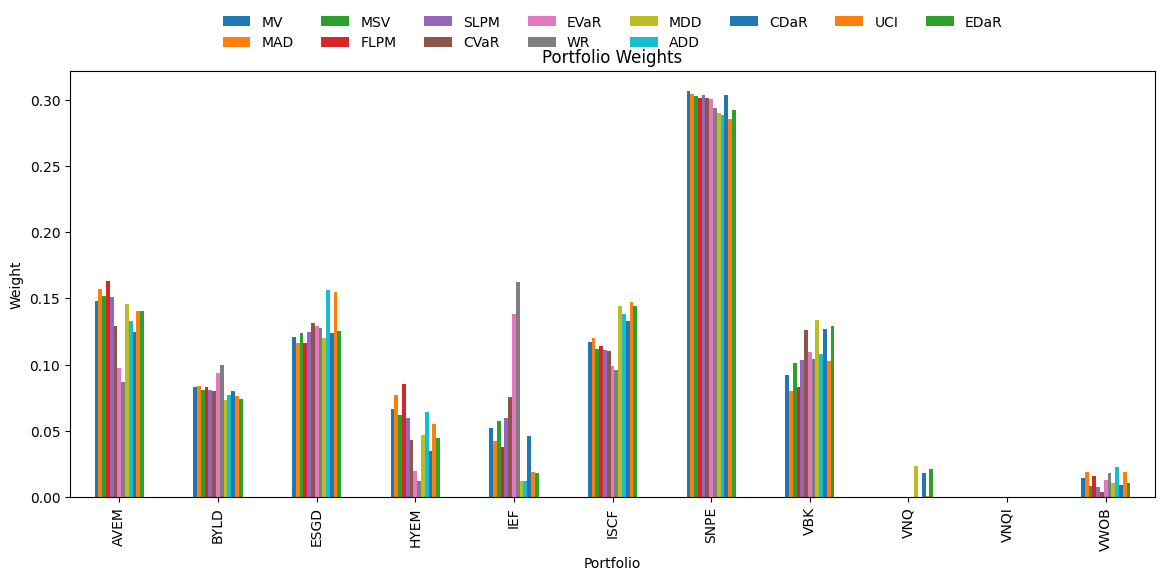

In [ ]:
import matplotlib.pyplot as plt

# Assume w_s is a DataFrame: rows = portfolios (or 1 row), columns = assets (weights)
# If it's a Series, convert first: w_s = w_s.to_frame().T

fig, ax = plt.subplots(figsize=(14, 6))
w_s.plot.bar(ax=ax)

ax.set_ylabel("Weight")
ax.set_xlabel("Portfolio" if w_s.shape[0] > 1 else "")
ax.set_title("Portfolio Weights")

# Move legend above plot, horizontal
handles, labels = ax.get_legend_handles_labels()
ncol = min(len(labels), 8)  # wrap if many assets
legend = ax.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=ncol,
    frameon=False,
)

# Add a little extra top margin for the legend
plt.subplots_adjust(top=0.82)

plt.show()

In [46]:
combos = [
    (MuEstimator.JS, CovEstimator.LEDOIT),
    (MuEstimator.JS, CovEstimator.SPECTRAL),
    (MuEstimator.EWMA2, CovEstimator.LEDOIT),
    (MuEstimator.EWMA2, CovEstimator.GERBER1),
    (MuEstimator.HIST, CovEstimator.HIST),
]

def portfolio_perf_stats(returns: pd.DataFrame, w, rf=0.0, periods_per_year=12, alpha=0.05):
    if hasattr(w, "T") and w.ndim == 2 and w.shape[0] == 1:
        w = w.iloc[0]
    w = w.reindex(returns.columns).fillna(0.0)
    port_ret = returns.dot(w)
    mean = port_ret.mean()
    vol = port_ret.std()
    ann_ret = (1 + mean)**periods_per_year - 1
    ann_vol = vol * np.sqrt(periods_per_year)
    sharpe = (mean - rf) / vol if vol > 0 else np.nan
    downside = port_ret[port_ret < rf] - rf
    dd_std = downside.std()
    sortino = (mean - rf) / dd_std if dd_std > 0 else np.nan
    cum = (1 + port_ret).cumprod()
    peak = cum.cummax()
    dd = cum / peak - 1
    mdd = dd.min()
    excess = port_ret - rf
    var = np.quantile(excess, alpha)
    cvar = excess[excess <= var].mean()
    return pd.DataFrame({
        "mean":[mean],
        "ann_return":[ann_ret],
        "vol":[vol],
        "ann_vol":[ann_vol],
        "sharpe":[sharpe],
        "sortino":[sortino],
        "max_drawdown":[mdd],
        "VaR":[var],
        "CVaR":[cvar]
    })

results = []
for mu_est, cov_est in combos:
    port = rp.Portfolio(returns=y)
    port.assets_stats(method_mu=mu_est.value,
                      method_cov=cov_est.value)
    w = port.optimization(model="Classic", rm="CVaR", obj="Sharpe", rf=0, l=0, hist=True)
    port_stats = portfolio_perf_stats(y, w.squeeze(), rf=0.0)
    results.append((mu_est, cov_est, port_stats))

print(results)

You must convert self.cov to a positive definite matrix
[(<MuEstimator.JS: 'JS'>, <CovEstimator.LEDOIT: 'ledoit'>,      mean  ann_return     vol  ann_vol  sharpe  sortino  max_drawdown  \
0 0.01169      0.1496 0.05004   0.1733  0.2336   0.3846       -0.2473   

       VaR     CVaR  
0 -0.08713 -0.09851  ), (<MuEstimator.JS: 'JS'>, <CovEstimator.SPECTRAL: 'spectral'>,      mean  ann_return     vol  ann_vol  sharpe  sortino  max_drawdown  \
0 0.01169      0.1496 0.05004   0.1733  0.2336   0.3846       -0.2473   

       VaR     CVaR  
0 -0.08713 -0.09851  ), (<MuEstimator.EWMA2: 'ewma2'>, <CovEstimator.LEDOIT: 'ledoit'>,      mean  ann_return     vol  ann_vol  sharpe  sortino  max_drawdown  \
0 0.01169      0.1496 0.05004   0.1733  0.2336   0.3846       -0.2473   

       VaR     CVaR  
0 -0.08713 -0.09851  ), (<MuEstimator.EWMA2: 'ewma2'>, <CovEstimator.GERBER1: 'gerber1'>,      mean  ann_return     vol  ann_vol  sharpe  sortino  max_drawdown  \
0 0.01169      0.1496 0.05004   0.1733  0

In [47]:

def asset_perf_stats(returns: pd.DataFrame, periods_per_year=12):
    mean = returns.mean()
    vol = returns.std()
    ann_ret = (1 + mean)**periods_per_year - 1
    ann_vol = vol * np.sqrt(periods_per_year)
    sharpe = mean / vol
    return pd.DataFrame({
        "mean": mean,
        "ann_return": ann_ret,
        "vol": vol,
        "ann_vol": ann_vol,
        "sharpe": sharpe
    })

asset_stats = asset_perf_stats(y)
asset_stats

,mean,ann_return,vol,ann_vol,sharpe
AVEM,0.006705,0.08349,0.05284,0.183,0.1269
BYLD,-0.0003618,-0.004332,0.01639,0.05678,-0.02207
ESGD,0.005933,0.07357,0.04893,0.1695,0.1212
HYEM,0.001015,0.01225,0.03152,0.1092,0.03221
IEF,-0.002188,-0.02594,0.02124,0.07357,-0.103
ISCF,0.006461,0.08034,0.05278,0.1828,0.1224
SNPE,0.01169,0.1496,0.05004,0.1733,0.2336
VBK,0.007064,0.08815,0.06556,0.2271,0.1078
VNQ,0.002111,0.02563,0.05797,0.2008,0.03641
VNQI,-0.001065,-0.0127,0.0526,0.1822,-0.02024


In [49]:
import numpy as np, pandas as pd, riskfolio as rp

def nearest_pd(A: np.ndarray):
    # Higham (2002) projection
    B = (A + A.T) / 2
    eigvals, eigvecs = np.linalg.eigh(B)
    eigvals[eigvals < 0] = 0
    return (eigvecs * eigvals) @ eigvecs.T

def optimize_once(returns, mu_est, cov_est):
    port = rp.Portfolio(returns=returns)
    port.assets_stats(method_mu=mu_est.value, method_cov=cov_est.value)
    # Check PD
    eigs = np.linalg.eigvalsh(port.cov)
    if np.min(eigs) < 1e-10:
        # Add ridge
        port.cov = port.cov + np.eye(port.cov.shape[0]) * (1e-6 - min(0, np.min(eigs)) + 1e-6)
    w = port.optimization(model="Classic", rm="MV", obj="Sharpe", rf=0, l=0, hist=False)
    return w, port

# Compare eigenvalues
def cov_diagnostics(port):
    eigs = np.linalg.eigvalsh(port.cov)
    return {
        "min_eig": float(eigs.min()),
        "cond": float(np.linalg.cond(port.cov)),
        "trace": float(np.trace(port.cov))
    }

# Example loop (assuming enums defined)
tests = [
    (MuEstimator.JS, CovEstimator.LEDOIT),
    (MuEstimator.JS, CovEstimator.SPECTRAL),
    (MuEstimator.EWMA2, CovEstimator.LEDOIT),
    (MuEstimator.EWMA2, CovEstimator.GERBER1),
    (MuEstimator.HIST, CovEstimator.HIST),
]

results = []
for mu_est, cov_est in tests:
    try:
        w, port = optimize_once(y, mu_est, cov_est)
        stats = cov_diagnostics(port)
        results.append((mu_est, cov_est, w.T, stats))
    except Exception as e:
        results.append((mu_est, cov_est, None, {"error": str(e)}))

for r in results:
    print(r[0], r[1], r[3])

You must convert self.cov to a positive definite matrix
JS ledoit {'min_eig': 0.0001565921554387973, 'cond': 113.34427224965425, 'trace': 0.02332845537566213}
JS spectral {'min_eig': 2.887759885918197e-10, 'cond': 81921646.75257124, 'trace': 0.023657025169685552}
ewma2 ledoit {'min_eig': 0.0001565921554387973, 'cond': 113.34427224965425, 'trace': 0.02332845537566213}
ewma2 gerber1 {'min_eig': 0.00012388085485339856, 'cond': 106.67535736722239, 'trace': 0.023328455375662138}
hist hist {'min_eig': 1.1783229408729904e-05, 'cond': 1626.7640627822266, 'trace': 0.02365702516968554}


In [50]:
import numpy as np

# Extract only non-None weight arrays
all_w = [r[2] for r in results if r[2] is not None]

# Normalize everything to 1-D numpy arrays
norm_w = []
for w in all_w:
    if hasattr(w, "values"):      # DataFrame / Series
        arr = w.values.squeeze()
    else:
        arr = np.asarray(w).squeeze()
    norm_w.append(arr)

# Sanity: all same length?
lengths = {a.shape for a in norm_w}
if len(lengths) != 1:
    raise ValueError(f"Inconsistent shapes: {lengths}")

base = norm_w[0]
for i, w in enumerate(norm_w[1:], start=1):
    l1 = np.sum(np.abs(w - base))
    l2 = np.sqrt(np.sum((w - base)**2))
    max_abs = np.max(np.abs(w - base))
    print(f"Diff vs first weight vector #{i}: L1={l1:.6g}  L2={l2:.6g}  max|Δ|={max_abs:.6g}")

# If you want a tolerance check:
tol = 1e-6
all_equal = all(np.allclose(base, w, atol=tol, rtol=0) for w in norm_w[1:])
print("All equal within tol:", all_equal)

# Assuming each w is a (1 x N) DataFrame
w_df = [w if hasattr(w, "values") else pd.DataFrame(w).T for w in all_w]
base = w_df[0].iloc[0]
for i, w in enumerate(w_df[1:], start=1):
    diff = (w.iloc[0] - base).abs()
    print(f"Diff vs first #{i}: L1={diff.sum():.6g}  max|Δ|={diff.max():.6g}")

Diff vs first weight vector #1: L1=7.53994e-10  L2=3.97704e-10  max|Δ|=3.76997e-10
Diff vs first weight vector #2: L1=0.997808  L2=0.705557  max|Δ|=0.498904
Diff vs first weight vector #3: L1=1.14277  L2=0.722885  max|Δ|=0.571384
Diff vs first weight vector #4: L1=1.83435e-09  L2=9.74233e-10  max|Δ|=9.17173e-10
All equal within tol: False
Diff vs first #1: L1=7.53994e-10  max|Δ|=3.76997e-10
Diff vs first #2: L1=0.997808  max|Δ|=0.498904
Diff vs first #3: L1=1.14277  max|Δ|=0.571384
Diff vs first #4: L1=1.83435e-09  max|Δ|=9.17173e-10


Small λ_min / huge κ amplify estimation noise, leading to extreme or unstable MV / Sharpe weights


If you need a dependable benchmark portfolio: use JS + Ledoit.
If recent months show sharp volatility clustering or correlation spikes and you want the model to react: test EWMA2 + Gerber1.
You can blend: use JS mean but Gerber1 covariance (stable expected returns + tail‑robust risk) or EWMA2 mean with Ledoit covariance (fast mean, stable Σ).